In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/Graduation Project/Text/Autism-Adult-Data.arff"

In [ ]:
import pandas as pd
from scipy.io import arff
import io

# Load the .arff file
data, meta = arff.loadarff(path)

# Convert to pandas DataFrame
df = pd.DataFrame(data)

# Decode byte strings to normal strings for object columns
for col in df.select_dtypes(['object']).columns:
    df[col] = df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

# Display the first few rows of the DataFrame
print("DataFrame loaded successfully. Here are the first 5 rows:")
display(df.head())

DataFrame loaded successfully. Here are the first 5 rows:


,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,United States,no,6.0,18 and more,Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5.0,18 and more,Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8.0,18 and more,Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,United States,no,6.0,18 and more,Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2.0,18 and more,?,NO


In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
# ====== 3) SPLIT X, y ======
TARGET_COL = "Class/ASD"
tar_tan=["A1_Score","A2_Score","A3_Score","A4_Score","A5_Score","A6_Score","A7_Score","A8_Score","A9_Score","A10_Score"]
y = df[TARGET_COL]
X = df[tar_tan]

# encode target YES/NO → 1/0
le = LabelEncoder()
y = le.fit_transform(y)


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize a base estimator (Decision Tree is common for AdaBoost)
base_estimator = DecisionTreeClassifier(max_depth=1)

# Initialize AdaBoost Classifier
adaboost_model = AdaBoostClassifier(estimator=base_estimator, n_estimators=50, random_state=42)

# Train the AdaBoost model
adaboost_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_ada = adaboost_model.predict(X_test)

# Evaluate the model
accuracy_ada = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost Model Accuracy: {accuracy_ada:.4f}")

AdaBoost Model Accuracy: 1.0000


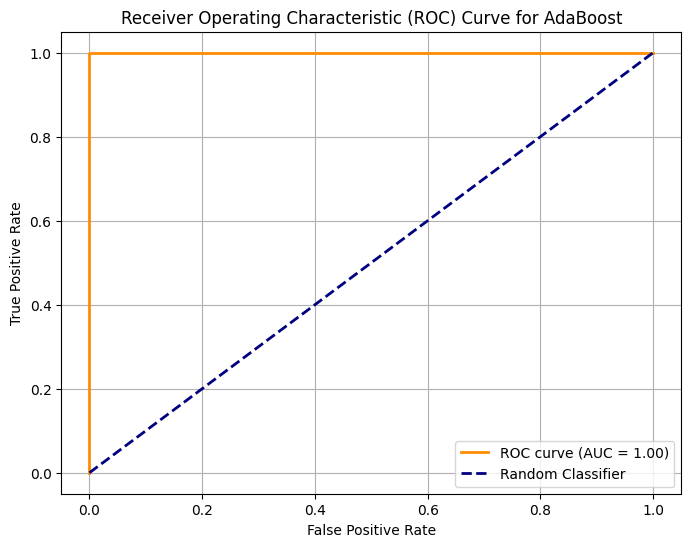

AUC Score for AdaBoost Model: 1.0000


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_pred_proba_ada = adaboost_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_ada)

# Calculate AUC
auc_score = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for AdaBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC Score for AdaBoost Model: {auc_score:.4f}")

In [ ]:
# Evaluate training accuracy
train_accuracy_ada = adaboost_model.score(X_train, y_train)
print(f"AdaBoost Model Training Accuracy: {train_accuracy_ada:.4f}")

# Evaluate testing accuracy
test_accuracy_ada = adaboost_model.score(X_test, y_test)
print(f"AdaBoost Model Testing Accuracy: {test_accuracy_ada:.4f}")

AdaBoost Model Training Accuracy: 1.0000
AdaBoost Model Testing Accuracy: 1.0000


In [ ]:
import joblib
import os

# Define the folder path to save the model
model_folder = "/content/drive/MyDrive/Graduation Project/models"

# Create the folder if it doesn't exist
os.makedirs(model_folder, exist_ok=True)

# Define the full path for the model file
model_filename = os.path.join(model_folder, 'adaboost_model.joblib')

# Save the model
joblib.dump(adaboost_model, model_filename)

print(f"AdaBoost model saved successfully to: {model_filename}")

AdaBoost model saved successfully to: /content/drive/MyDrive/Graduation Project/models/adaboost_model.joblib


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Initialize XGBoost Classifier
# Set use_label_encoder=False and eval_metric='logloss' for compatibility and to suppress warnings
# Set random_state for reproducibility
xgboost_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Train the XGBoost model
xgboost_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgboost_model.predict(X_test)

# Calculate and print the initial test accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Model Test Accuracy: {accuracy_xgb:.4f}")

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:A1_Score: object, A2_Score: object, A3_Score: object, A4_Score: object, A5_Score: object, A6_Score: object, A7_Score: object, A8_Score: object, A9_Score: object, A10_Score: object

**Reasoning**:
The XGBoost model failed because the input features (`X_train`) were of `object` dtype, as indicated by the `ValueError`. I need to convert these feature columns to a numerical type (e.g., integer) before training the model.



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Convert object columns to numeric (int) before passing to XGBoost
# X_train and X_test contain 'A1_Score' through 'A10_Score' which are currently objects.
for col in X_train.columns:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

# Initialize XGBoost Classifier
# Set use_label_encoder=False and eval_metric='logloss' for compatibility and to suppress warnings
# Set random_state for reproducibility
xgboost_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Train the XGBoost model
xgboost_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgboost_model.predict(X_test)

# Calculate and print the initial test accuracy
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Model Test Accuracy: {accuracy_xgb:.4f}")

XGBoost Model Test Accuracy: 0.9716


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [12:35:47] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**Reasoning**:
The previous step successfully trained the XGBoost model and calculated its test accuracy. The next step, as per the task description, is to generate and display the AUC-ROC curve for the trained XGBoost model. This involves calculating predicted probabilities, then using `roc_curve` and `auc` from `sklearn.metrics` and plotting with `matplotlib`.



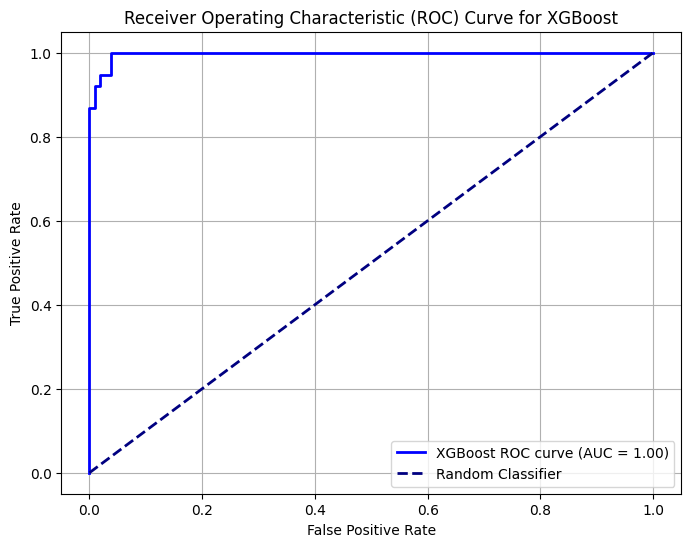

AUC Score for XGBoost Model: 0.9969


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_pred_proba_xgb = xgboost_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)

# Calculate AUC
auc_score_xgb = auc(fpr_xgb, tpr_xgb)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='blue', lw=2, label=f'XGBoost ROC curve (AUC = {auc_score_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC Score for XGBoost Model: {auc_score_xgb:.4f}")

**Reasoning**:
The next step is to save the trained XGBoost model to the specified directory, and then summarize its performance, which includes its test accuracy and AUC score. I will use `joblib.dump` to save the model and then a markdown block to provide the summary.



In [ ]:
import joblib
import os

# Define the folder path to save the model (already created in previous steps)
model_folder = "/content/drive/MyDrive/Graduation Project/models"

# Define the full path for the XGBoost model file
xgboost_model_filename = os.path.join(model_folder, 'xgboost_model.joblib')

# Save the XGBoost model
joblib.dump(xgboost_model, xgboost_model_filename)

print(f"XGBoost model saved successfully to: {xgboost_model_filename}")

# Summarize the model's performance
print("\n--- XGBoost Model Performance Summary ---")
print(f"Test Accuracy: {accuracy_xgb:.4f}")
print(f"AUC Score: {auc_score_xgb:.4f}")
print("-----------------------------------------")

XGBoost model saved successfully to: /content/drive/MyDrive/Graduation Project/models/xgboost_model.joblib

--- XGBoost Model Performance Summary ---
Test Accuracy: 0.9716
AUC Score: 0.9969
-----------------------------------------


In [ ]:
train_accuracy_xgb = xgboost_model.score(X_train, y_train)
print(f"XGBoost Model Training Accuracy: {train_accuracy_xgb:.4f}")

XGBoost Model Training Accuracy: 1.0000


In [ ]:
test_accuracy_xgb = xgboost_model.score(X_test, y_test)
print(f"XGBoost Model Testing Accuracy: {test_accuracy_xgb:.4f}")

XGBoost Model Testing Accuracy: 0.9716


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)

# Train the RandomForest model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate and print the initial test accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"RandomForest Model Test Accuracy: {accuracy_rf:.4f}")

RandomForest Model Test Accuracy: 0.9645


In [ ]:
train_accuracy_rf = rf_model.score(X_train, y_train)
print(f"RandomForest Model Training Accuracy: {train_accuracy_rf:.4f}")

test_accuracy_rf = rf_model.score(X_test, y_test)
print(f"RandomForest Model Testing Accuracy: {test_accuracy_rf:.4f}")

RandomForest Model Training Accuracy: 1.0000
RandomForest Model Testing Accuracy: 0.9645


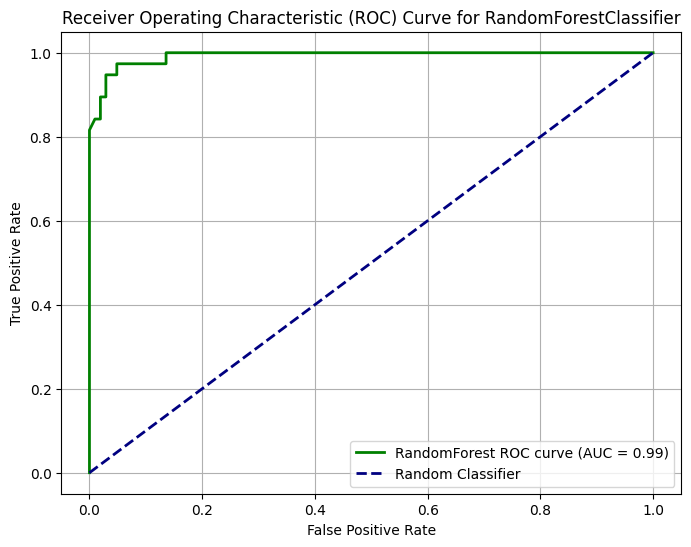

AUC Score for RandomForest Model: 0.9925


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)

# Calculate AUC
auc_score_rf = auc(fpr_rf, tpr_rf)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'RandomForest ROC curve (AUC = {auc_score_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for RandomForestClassifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"AUC Score for RandomForest Model: {auc_score_rf:.4f}")

In [ ]:
import joblib
import os

# Define the folder path to save the model (already created in previous steps)
model_folder = "/content/drive/MyDrive/Graduation Project/models"

# Define the full path for the RandomForest model file
random_forest_model_filename = os.path.join(model_folder, 'random_forest_model.joblib')

# Save the RandomForest model
joblib.dump(rf_model, random_forest_model_filename)

print(f"RandomForest model saved successfully to: {random_forest_model_filename}")

RandomForest model saved successfully to: /content/drive/MyDrive/Graduation Project/models/random_forest_model.joblib


In [ ]:
import joblib
import os

# Define the folder path where models are saved
model_folder = "/content/drive/MyDrive/Graduation Project/models"

# Load the AdaBoost model
adaboost_model = joblib.load(os.path.join(model_folder, 'adaboost_model.joblib'))
print(f"AdaBoost model loaded from: {os.path.join(model_folder, 'adaboost_model.joblib')}")

# Load the XGBoost model
xgboost_model = joblib.load(os.path.join(model_folder, 'xgboost_model.joblib'))
print(f"XGBoost model loaded from: {os.path.join(model_folder, 'xgboost_model.joblib')}")

# Load the RandomForest model
rf_model = joblib.load(os.path.join(model_folder, 'random_forest_model.joblib'))
print(f"RandomForest model loaded from: {os.path.join(model_folder, 'random_forest_model.joblib')}")

AdaBoost model loaded from: /content/drive/MyDrive/Graduation Project/models/adaboost_model.joblib
XGBoost model loaded from: /content/drive/MyDrive/Graduation Project/models/xgboost_model.joblib
RandomForest model loaded from: /content/drive/MyDrive/Graduation Project/models/random_forest_model.joblib


In [ ]:
import pandas as pd

# Define the AQ-10 question names based on the features used for training
aq10_questions = [
    "A1_Score", "A2_Score", "A3_Score", "A4_Score", "A5_Score",
    "A6_Score", "A7_Score", "A8_Score", "A9_Score", "A10_Score"
]

user_input = []
print("Please enter your score (0 or 1) for each of the following AQ-10 questions:")

for i, question in enumerate(aq10_questions):
    while True:
        try:
            score = int(input(f"Enter score for {question} (0 or 1): "))
            if score in [0, 1]:
                user_input.append(score)
                break
            else:
                print("Invalid input. Please enter 0 or 1.")
        except ValueError:
            print("Invalid input. Please enter a number.")

# Prepare the user input as a DataFrame for prediction
user_df = pd.DataFrame([user_input], columns=aq10_questions)

print("\nUser input collected successfully:")
print(user_df)

Please enter your score (0 or 1) for each of the following AQ-10 questions:
Enter score for A1_Score (0 or 1): 1
Enter score for A2_Score (0 or 1): 
Invalid input. Please enter a number.
Enter score for A2_Score (0 or 1): 0
Enter score for A3_Score (0 or 1): 0
Enter score for A4_Score (0 or 1): 0
Enter score for A5_Score (0 or 1): 0
Enter score for A6_Score (0 or 1): 0
Enter score for A7_Score (0 or 1): 0
Enter score for A8_Score (0 or 1): 0
Enter score for A9_Score (0 or 1): 0
Enter score for A10_Score (0 or 1): 0

User input collected successfully:
   A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0         1         0         0         0         0         0         0   

   A8_Score  A9_Score  A10_Score  
0         0         0          0  


In [ ]:
print("\n--- Prediction Results ---")

# AdaBoost Prediction
adaboost_prediction = adaboost_model.predict(user_df)
adaboost_proba = adaboost_model.predict_proba(user_df)[:, 1]
print(f"AdaBoost Prediction: {'Positive for ASD' if adaboost_prediction[0] == 1 else 'Negative for ASD'} (Probability: {adaboost_proba[0]:.4f})")

# XGBoost Prediction
xgboost_prediction = xgboost_model.predict(user_df)
xgboost_proba = xgboost_model.predict_proba(user_df)[:, 1]
print(f"XGBoost Prediction: {'Positive for ASD' if xgboost_prediction[0] == 1 else 'Negative for ASD'} (Probability: {xgboost_proba[0]:.4f})")

# RandomForest Prediction
rf_prediction = rf_model.predict(user_df)
rf_proba = rf_model.predict_proba(user_df)[:, 1]
print(f"RandomForest Prediction: {'Positive for ASD' if rf_prediction[0] == 1 else 'Negative for ASD'} (Probability: {rf_proba[0]:.4f})")

print("--------------------------")


--- Prediction Results ---
AdaBoost Prediction: Negative for ASD (Probability: 0.1590)
XGBoost Prediction: Negative for ASD (Probability: 0.0000)
RandomForest Prediction: Negative for ASD (Probability: 0.0000)
--------------------------


In [ ]:
print("\n--- Model Performance Summary ---")

print("\nAdaBoost Model:")
print(f"  Training Accuracy: {train_accuracy_ada:.4f}")
print(f"  Testing Accuracy: {test_accuracy_ada:.4f}")
print(f"  AUC Score: {auc_score:.4f}")

print("\nXGBoost Model:")
print(f"  Training Accuracy: {train_accuracy_xgb:.4f}")
print(f"  Testing Accuracy: {test_accuracy_xgb:.4f}")
print(f"  AUC Score: {auc_score_xgb:.4f}")

print("\nRandomForest Model:")
print(f"  Training Accuracy: {train_accuracy_rf:.4f}")
print(f"  Testing Accuracy: {test_accuracy_rf:.4f}")
print(f"  AUC Score: {auc_score_rf:.4f}")

print("-----------------------------------")


--- Model Performance Summary ---

AdaBoost Model:
  Training Accuracy: 1.0000
  Testing Accuracy: 1.0000
  AUC Score: 1.0000

XGBoost Model:
  Training Accuracy: 1.0000
  Testing Accuracy: 0.9716
  AUC Score: 0.9969

RandomForest Model:
  Training Accuracy: 1.0000
  Testing Accuracy: 0.9645
  AUC Score: 0.9925
-----------------------------------
